## Urszula Michalska, Natalia Rogalska


In [1]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import time

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [3]:
param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': range(5, 15),
    'max_features': range(2, 8),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': range(2, 5),
    'min_samples_leaf': range(1, 5),
    'bootstrap': [True, False]
}


rf = RandomForestClassifier(
    random_state=1000
)

start = time.perf_counter()

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=50,              
    scoring='accuracy',       
    cv=5,                   
    random_state=1000,      
    n_jobs=-1,              
    verbose=2
)


random_search.fit(X_train, y_train)
end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")
start = time.perf_counter()

best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_recall = random_search.best_score_

print("Best Parameters:", best_params)
print("Best Recall (CV):", best_recall)


y_pred_best = best_model.predict(X_test)
end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")



Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Elapsed time: 41.280878 seconds
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 7, 'max_depth': 14, 'criterion': 'entropy', 'bootstrap': False}
Best Recall (CV): 0.770725210260094
Elapsed time: 0.061470 seconds


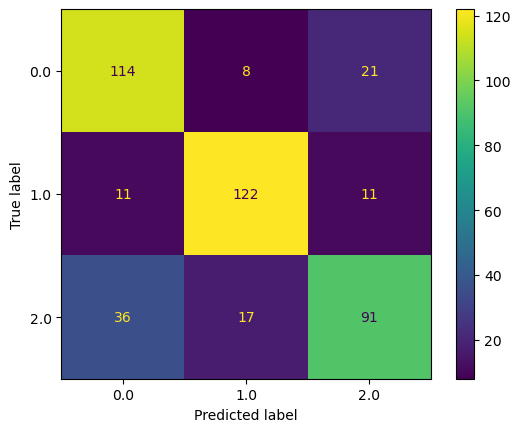

In [4]:
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot()

In [5]:
class_report = classification_report(y_test, y_pred_best)
print("Classification Report:")
print(class_report)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.80      0.75       143
         1.0       0.83      0.85      0.84       144
         2.0       0.74      0.63      0.68       144

    accuracy                           0.76       431
   macro avg       0.76      0.76      0.76       431
weighted avg       0.76      0.76      0.76       431

Accuracy: 0.7587006960556845
